# Garbage Classification — BaseCNN 증강 비교 실험

새 EDA 결과를 사용하여 BaseCNN의 **증강 미적용/적용** 조건을 공정하게 비교합니다.

실험 원칙:

- 동일한 그룹 기반 Train/Validation/Test 분할을 모든 실험에서 공유합니다.
- 단순 다수 클래스 예측을 최소 기준선으로 계산합니다.
- 모델 선택의 주 지표는 클래스 불균형을 고려한 **Macro F1**입니다.
- 증강 이외의 모델 구조와 학습 조건은 동일하게 유지합니다.
- 증강 효과의 가설검정과 신뢰도 임계값별 지표 변화를 Validation에서 분석합니다.
- Test는 모든 결정이 끝난 후 최종 모델을 한 번 평가할 때 사용합니다.


In [14]:
from pathlib import Path
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedGroupKFold

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm

ImageFile.LOAD_TRUNCATED_IMAGES = True


## 1. 실험 설정

두 실험은 아래 설정을 공유합니다. `EPOCHS`는 최대 학습 횟수이며, Validation Macro F1이 `PATIENCE`회 연속 개선되지 않으면 조기 종료합니다.


In [15]:
SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0  # Windows/Jupyter에서 안전한 값
EPOCHS = 100
PATIENCE = 10
LEARNING_RATE = 1e-3
ALPHA = 0.05
N_PERMUTATIONS = 5000

PROJECT_DIR = Path.cwd()
METADATA_PATH = PROJECT_DIR / 'garbage_clean_metadata_final.csv'
CHECKPOINT_DIR = PROJECT_DIR / 'checkpoints'
RESULT_DIR = PROJECT_DIR / 'results'
CHECKPOINT_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('project:', PROJECT_DIR)
print('device :', device)
if device.type == 'cuda':
    print('GPU    :', torch.cuda.get_device_name(0))
assert METADATA_PATH.exists(), f'파일을 찾을 수 없습니다: {METADATA_PATH}'


project: c:\Users\KDS-30\Desktop\Projects\04_Team_Projcet3
device : cuda
GPU    : NVIDIA GeForce RTX 5060 Laptop GPU


In [16]:
def reset_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

reset_seed()


## 2. 정제 메타데이터 로드 및 고정 분할

`split_group`을 기준으로 약 70/15/15로 나눕니다. 같은 원본에서 파생된 근접 중복 이미지는 서로 다른 데이터 세트에 들어갈 수 없습니다.

분할 CSV가 이미 있으면 그대로 불러오므로 이후 모델도 정확히 같은 데이터를 사용할 수 있습니다.


In [17]:
df = pd.read_csv(METADATA_PATH)
required = {'path', 'class_name', 'split_group'}
assert required.issubset(df.columns), f'필수 컬럼 누락: {required - set(df.columns)}'
if 'include_in_model' in df.columns:
    df = df[df['include_in_model'].astype(str).str.lower().eq('true')].copy()
df = df.dropna(subset=['path', 'class_name', 'split_group']).reset_index(drop=True)

def resolve_image_path(value):
    candidate = Path(str(value).replace('\\', '/'))
    return candidate if candidate.is_absolute() else PROJECT_DIR / candidate

df['resolved_path'] = df['path'].map(resolve_image_path)
missing = df.loc[~df['resolved_path'].map(Path.exists), 'resolved_path']
assert missing.empty, f'이미지 {len(missing)}개를 찾을 수 없습니다. 예: {missing.iloc[0]}'

class_names = sorted(df['class_name'].unique())
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
idx_to_class = {idx: name for name, idx in class_to_idx.items()}
NUM_CLASSES = len(class_names)
print(f'사용 이미지: {len(df):,}장 / 클래스: {NUM_CLASSES}개')
display(df['class_name'].value_counts().sort_index().to_frame('count'))


사용 이미지: 15,486장 / 클래스: 12개


,count
class_name,
battery,945
biological,985
brown-glass,607
cardboard,891
clothes,5281
green-glass,614
metal,767
paper,1048
plastic,864


In [18]:
split_paths = {
    'train': PROJECT_DIR / 'train_metadata_final.csv',
    'val': PROJECT_DIR / 'val_metadata_final.csv',
    'test': PROJECT_DIR / 'test_metadata_final.csv',
}

if all(path.exists() for path in split_paths.values()):
    print('기존 고정 분할 CSV를 불러옵니다.')
    train_df = pd.read_csv(split_paths['train'])
    val_df = pd.read_csv(split_paths['val'])
    test_df = pd.read_csv(split_paths['test'])
else:
    print('고정 분할 CSV를 새로 생성합니다.')
    sgkf = StratifiedGroupKFold(n_splits=20, shuffle=True, random_state=SEED)
    df['fold'] = -1
    for fold, (_, holdout_idx) in enumerate(sgkf.split(df, y=df['class_name'], groups=df['split_group'])):
        df.loc[holdout_idx, 'fold'] = fold
    assert (df['fold'] >= 0).all()
    df['split'] = np.select(
        [df['fold'].between(0, 13), df['fold'].between(14, 16)],
        ['train', 'val'], default='test'
    )
    train_df = df[df['split'].eq('train')].copy()
    val_df = df[df['split'].eq('val')].copy()
    test_df = df[df['split'].eq('test')].copy()
    save_columns = [c for c in df.columns if c != 'resolved_path']
    train_df[save_columns].to_csv(split_paths['train'], index=False)
    val_df[save_columns].to_csv(split_paths['val'], index=False)
    test_df[save_columns].to_csv(split_paths['test'], index=False)

for part in (train_df, val_df, test_df):
    part['resolved_path'] = part['path'].map(resolve_image_path)
    part.reset_index(drop=True, inplace=True)

train_groups, val_groups, test_groups = map(
    lambda x: set(x['split_group']), (train_df, val_df, test_df)
)
assert train_groups.isdisjoint(val_groups)
assert train_groups.isdisjoint(test_groups)
assert val_groups.isdisjoint(test_groups)
assert all(set(part.class_name) == set(class_names) for part in (train_df, val_df, test_df))

for name, part in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'{name:5s}: {len(part):5d}장 ({len(part)/len(df):.2%}), 그룹 {part.split_group.nunique():5d}개')
print('검증 완료: split_group 누수 없음, 모든 분할에 12개 클래스 존재')


기존 고정 분할 CSV를 불러옵니다.
train: 10842장 (70.01%), 그룹 10822개
val  :  2322장 (14.99%), 그룹  2319개
test :  2322장 (14.99%), 그룹  2318개
검증 완료: split_group 누수 없음, 모든 분할에 12개 클래스 존재


## 3. 최소 기준선: 다수 클래스 예측

학습 없이 모든 Validation 이미지를 Train에서 가장 많은 클래스라고 예측합니다. 이후 신경망이 이 점수보다 충분히 나은지 확인하는 최소 기준입니다.


In [19]:
majority_class = train_df['class_name'].value_counts().idxmax()
majority_idx = class_to_idx[majority_class]
val_true_baseline = val_df['class_name'].map(class_to_idx).to_numpy()
val_pred_baseline = np.full(len(val_df), majority_idx)

baseline_metrics = {
    'model': f'Majority ({majority_class})',
    'val_accuracy': accuracy_score(val_true_baseline, val_pred_baseline),
    'val_balanced_accuracy': balanced_accuracy_score(val_true_baseline, val_pred_baseline),
    'val_macro_f1': f1_score(val_true_baseline, val_pred_baseline, average='macro', zero_division=0),
}
display(pd.DataFrame([baseline_metrics]))


,model,val_accuracy,val_balanced_accuracy,val_macro_f1
0,Majority (clothes),0.341085,0.083333,0.042389


## 4. 증강 조건

### 증강 미적용

크기 변환과 정규화만 적용하여 기본 데이터의 성능을 측정합니다.

### 증강 적용

- `RandomResizedCrop`: 물체 크기와 촬영 거리 변화 대응
- `RandomHorizontalFlip`: 좌우 방향 변화 대응
- `RandomRotation`: 촬영 각도 변화 대응
- 약한 `ColorJitter`: 조명 차이 대응

유리 클래스는 색상이 라벨의 핵심이므로 색조(`hue`)는 바꾸지 않고 밝기·대비·채도만 약하게 조절합니다. 랜덤 증강은 Train에만 적용합니다.


In [20]:
normalize = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

no_aug_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    normalize,
])

aug_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.0),
    transforms.ToTensor(),
    normalize,
])

eval_transform = no_aug_transform


In [21]:
class GarbageDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(row['resolved_path']) as image:
            image = self.transform(image.convert('RGB'))
        return image, class_to_idx[row['class_name']], str(row['resolved_path'])

def make_loaders(train_transform, seed=SEED):
    train_dataset = GarbageDataset(train_df, train_transform)
    val_dataset = GarbageDataset(val_df, eval_transform)
    test_dataset = GarbageDataset(test_df, eval_transform)
    common = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
                  pin_memory=(device.type == 'cuda'))
    generator = torch.Generator().manual_seed(seed)
    return (
        DataLoader(train_dataset, shuffle=True, generator=generator, **common),
        DataLoader(val_dataset, shuffle=False, **common),
        DataLoader(test_dataset, shuffle=False, **common),
    )


## 5. BaseCNN 정의

두 실험은 같은 초기 가중치가 생성되도록 실행 직전에 난수 시드를 다시 고정합니다.


In [22]:
class BaseCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.4), nn.Linear(256, num_classes))

    def forward(self, x):
        return self.classifier(self.features(x))

probe = BaseCNN(NUM_CLASSES)
print(probe)
print(f'학습 파라미터: {sum(p.numel() for p in probe.parameters()):,}')
del probe


BaseCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(2

## 6. 공통 학습 함수

손실함수는 다중 분류용 `CrossEntropyLoss`, 최적화 알고리즘은 Adam입니다. 최고 모델 저장과 Early Stopping은 Validation Macro F1을 기준으로 합니다.


In [23]:
def collect_predictions(model, loader, criterion=None):
    model.eval()
    total_loss = 0.0
    targets_all, preds_all, probs_all, paths_all = [], [], [], []
    with torch.inference_mode():
        for images, targets, paths in tqdm(loader, leave=False):
            images = images.to(device, non_blocking=True)
            targets_device = targets.to(device, non_blocking=True)
            logits = model(images)
            if criterion is not None:
                total_loss += criterion(logits, targets_device).item() * images.size(0)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            targets_all.extend(targets.numpy())
            preds_all.extend(probs.argmax(axis=1))
            probs_all.extend(probs)
            paths_all.extend(paths)
    targets_all = np.asarray(targets_all)
    preds_all = np.asarray(preds_all)
    probs_all = np.asarray(probs_all)
    return {
        'loss': total_loss / len(loader.dataset) if criterion is not None else None,
        'accuracy': accuracy_score(targets_all, preds_all),
        'balanced_accuracy': balanced_accuracy_score(targets_all, preds_all),
        'macro_f1': f1_score(targets_all, preds_all, average='macro', zero_division=0),
        'targets': targets_all, 'preds': preds_all, 'probs': probs_all, 'paths': paths_all,
    }

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    targets_all, preds_all = [], []
    for images, targets, _ in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        targets_all.extend(targets.cpu().numpy())
        preds_all.extend(logits.argmax(1).detach().cpu().numpy())
    return {
        'loss': total_loss / len(loader.dataset),
        'accuracy': accuracy_score(targets_all, preds_all),
        'macro_f1': f1_score(targets_all, preds_all, average='macro', zero_division=0),
    }


In [24]:
def run_experiment(name, train_transform):
    reset_seed(SEED)
    train_loader, val_loader, test_loader = make_loaders(train_transform, SEED)
    model = BaseCNN(NUM_CLASSES).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3, min_lr=1e-6
    )
    checkpoint_path = CHECKPOINT_DIR / f'{name}_best.pth'
    history, best_f1, patience_count = [], -1.0, 0
    started = time.time()

    for epoch in range(1, EPOCHS + 1):
        train_m = train_one_epoch(model, train_loader, criterion, optimizer)
        val_m = collect_predictions(model, val_loader, criterion)
        scheduler.step(val_m['macro_f1'])
        row = {
            'experiment': name, 'epoch': epoch, 'lr': optimizer.param_groups[0]['lr'],
            'train_loss': train_m['loss'], 'train_accuracy': train_m['accuracy'],
            'train_macro_f1': train_m['macro_f1'], 'val_loss': val_m['loss'],
            'val_accuracy': val_m['accuracy'], 'val_balanced_accuracy': val_m['balanced_accuracy'],
            'val_macro_f1': val_m['macro_f1'],
        }
        history.append(row)
        print(f"[{name}] {epoch:02d}/{EPOCHS} | train loss {train_m['loss']:.4f}, "
              f"acc {train_m['accuracy']:.4f} | val loss {val_m['loss']:.4f}, "
              f"acc {val_m['accuracy']:.4f}, macro F1 {val_m['macro_f1']:.4f}")

        if val_m['macro_f1'] > best_f1:
            best_f1, patience_count = val_m['macro_f1'], 0
            torch.save({'model_state_dict': model.state_dict(), 'class_names': class_names,
                        'best_epoch': epoch, 'best_val_macro_f1': best_f1}, checkpoint_path)
            print('  -> 최고 모델 저장')
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                print(f'Early stopping: {PATIENCE} epoch 동안 개선 없음')
                break

    history_df = pd.DataFrame(history)
    history_df.to_csv(RESULT_DIR / f'{name}_history.csv', index=False)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    val_result = collect_predictions(model, val_loader, criterion)
    print(f"{name} 완료: {((time.time()-started)/60):.1f}분, best epoch={checkpoint['best_epoch']}, "
          f"Validation Macro F1={val_result['macro_f1']:.4f}")
    return {'name': name, 'model': model, 'history': history_df, 'val': val_result,
            'test_loader': test_loader, 'checkpoint': checkpoint, 'checkpoint_path': checkpoint_path}


## 7. 실험 A — 증강 미적용 BaseCNN

기본 데이터 변환만 사용한 BaseCNN 기준 실험입니다.


In [25]:
no_aug_result = run_experiment('BaseCNN_NoAug', no_aug_transform)


  0%|          | 0/339 [00:00<?, ?it/s]

  0%|          | 0/73 [00:00<?, ?it/s]

[BaseCNN_NoAug] 01/100 | train loss 1.4264, acc 0.5267 | val loss 1.2552, acc 0.5792, macro F1 0.4632
  -> 최고 모델 저장


  0%|          | 0/339 [00:00<?, ?it/s]

  0%|          | 0/73 [00:00<?, ?it/s]

...

  0%|          | 0/339 [00:00<?, ?it/s]

  0%|          | 0/73 [00:00<?, ?it/s]

[BaseCNN_NoAug] 77/100 | train loss 0.2918, acc 0.9018 | val loss 0.4849, acc 0.8622, macro F1 0.8241
Early stopping: 10 epoch 동안 개선 없음


  0%|          | 0/73 [00:00<?, ?it/s]

BaseCNN_NoAug 완료: 69.1분, best epoch=67, Validation Macro F1=0.8291


## 8. 실험 B — 증강 적용 BaseCNN

모델과 학습 조건은 실험 A와 같고 Train 증강만 변경합니다.


In [26]:
aug_result = run_experiment('BaseCNN_Aug', aug_transform)


  0%|          | 0/339 [00:00<?, ?it/s]

  0%|          | 0/73 [00:00<?, ?it/s]

[BaseCNN_Aug] 01/100 | train loss 1.4888, acc 0.5100 | val loss 1.2994, acc 0.5551, macro F1 0.4440
  -> 최고 모델 저장


  0%|          | 0/339 [00:00<?, ?it/s]

  0%|          | 0/73 [00:00<?, ?it/s]

...

  0%|          | 0/339 [00:00<?, ?it/s]

  0%|          | 0/73 [00:00<?, ?it/s]

[BaseCNN_Aug] 67/100 | train loss 0.4413, acc 0.8522 | val loss 0.5563, acc 0.8217, macro F1 0.7772
Early stopping: 10 epoch 동안 개선 없음


  0%|          | 0/73 [00:00<?, ?it/s]

BaseCNN_Aug 완료: 75.9분, best epoch=57, Validation Macro F1=0.7888


## 9. Validation 결과 비교

Test를 확인하기 전에 두 실험을 Validation Macro F1로 비교합니다.


,model,val_accuracy,val_balanced_accuracy,val_macro_f1
0,Majority (clothes),0.341085,0.083333,0.042389
1,BaseCNN_NoAug,0.865202,0.825009,0.829073
2,BaseCNN_Aug,0.827304,0.792211,0.788815


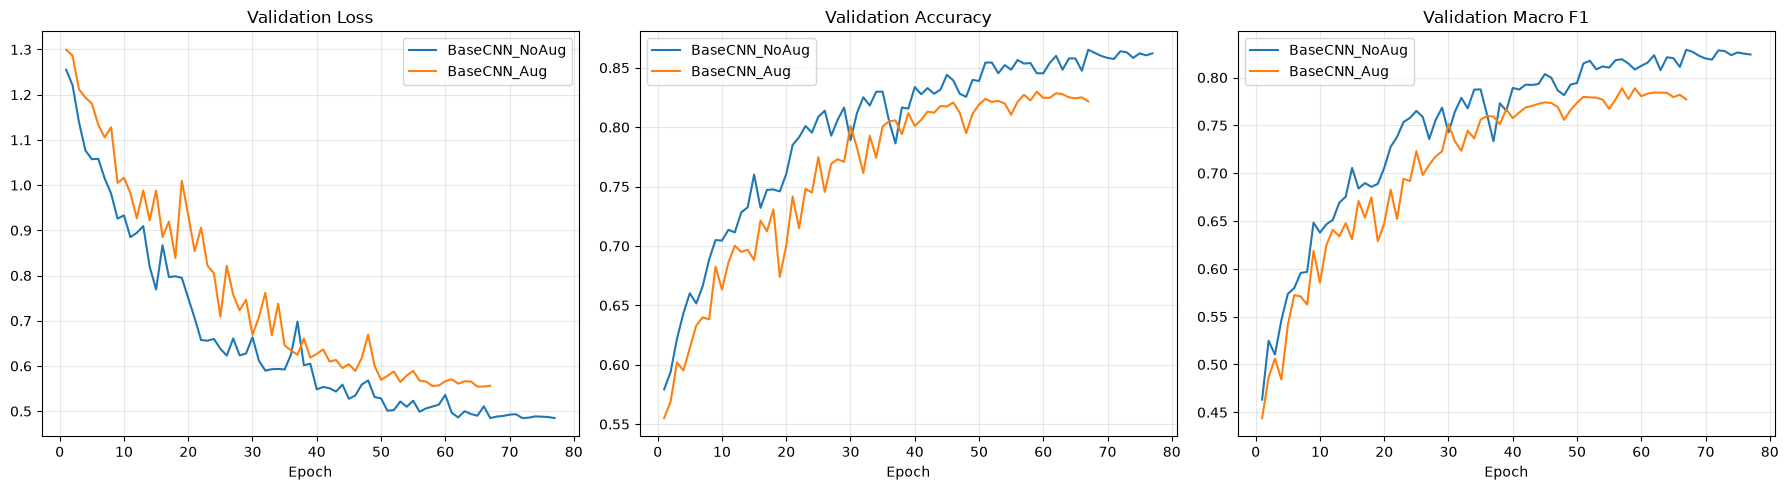

In [27]:
comparison = pd.DataFrame([
    baseline_metrics,
    {'model': 'BaseCNN_NoAug',
     'val_accuracy': no_aug_result['val']['accuracy'],
     'val_balanced_accuracy': no_aug_result['val']['balanced_accuracy'],
     'val_macro_f1': no_aug_result['val']['macro_f1']},
    {'model': 'BaseCNN_Aug',
     'val_accuracy': aug_result['val']['accuracy'],
     'val_balanced_accuracy': aug_result['val']['balanced_accuracy'],
     'val_macro_f1': aug_result['val']['macro_f1']},
])
comparison.to_csv(RESULT_DIR / 'BaseCNN_validation_comparison.csv', index=False)
display(comparison)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for result in (no_aug_result, aug_result):
    h, label = result['history'], result['name']
    axes[0].plot(h.epoch, h.val_loss, label=label)
    axes[1].plot(h.epoch, h.val_accuracy, label=label)
    axes[2].plot(h.epoch, h.val_macro_f1, label=label)
for ax, title in zip(axes, ['Validation Loss', 'Validation Accuracy', 'Validation Macro F1']):
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig(RESULT_DIR / 'BaseCNN_augmentation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. 증강 효과 가설검정

동일한 Validation 이미지에 대한 두 모델의 예측을 사용하여 **paired permutation test**를 수행합니다.

- 귀무가설 \(H_0\): 증강 적용 모델의 Macro F1이 증강 미적용 모델보다 높지 않다.
- 대립가설 \(H_1\): 증강 적용 모델의 Macro F1이 더 높다.
- 유의수준: \(lpha=0.05\)

각 이미지 쌍의 두 모델 예측을 무작위로 교환하여, 관측된 Macro F1 차이 이상이 우연히 발생하는 비율을 계산합니다. 이 검정은 이번에 학습된 두 모델의 Validation 예측 차이에 대한 검정입니다. 학습 자체의 난수 변동까지 일반화하려면 추후 여러 seed의 반복 실험이 필요합니다.


In [28]:
y_true = no_aug_result['val']['targets']
pred_no_aug = no_aug_result['val']['preds']
pred_aug = aug_result['val']['preds']
assert np.array_equal(y_true, aug_result['val']['targets'])

def macro_f1(y, pred):
    return f1_score(y, pred, labels=range(NUM_CLASSES), average='macro', zero_division=0)

observed_difference = macro_f1(y_true, pred_aug) - macro_f1(y_true, pred_no_aug)
rng = np.random.default_rng(SEED)
permuted_differences = np.empty(N_PERMUTATIONS)
for i in tqdm(range(N_PERMUTATIONS)):
    swap = rng.random(len(y_true)) < 0.5
    perm_a = np.where(swap, pred_aug, pred_no_aug)
    perm_b = np.where(swap, pred_no_aug, pred_aug)
    permuted_differences[i] = macro_f1(y_true, perm_b) - macro_f1(y_true, perm_a)

p_value = (np.sum(permuted_differences >= observed_difference) + 1) / (N_PERMUTATIONS + 1)
decision = 'H0 기각' if (observed_difference > 0 and p_value < ALPHA) else 'H0 기각하지 못함'
hypothesis_result = pd.DataFrame([{
    'H0': 'Aug Macro F1 <= NoAug Macro F1',
    'H1': 'Aug Macro F1 > NoAug Macro F1',
    'observed_macro_f1_difference': observed_difference,
    'alpha': ALPHA, 'p_value_one_sided': p_value, 'decision': decision,
}])
hypothesis_result.to_csv(RESULT_DIR / 'BaseCNN_augmentation_hypothesis_test.csv', index=False)
display(hypothesis_result)
print(f'결론: p-value={p_value:.4f}, {decision}')


  0%|          | 0/5000 [00:00<?, ?it/s]

,H0,H1,observed_macro_f1_difference,alpha,p_value_one_sided,decision
0,Aug Macro F1 <= NoAug Macro F1,Aug Macro F1 > NoAug Macro F1,-0.040258,0.05,1.0,H0 기각하지 못함


결론: p-value=1.0000, H0 기각하지 못함


## 11. 신뢰도 임계값에 따른 지표 변화

12개 클래스 다중 분류는 기본적으로 최고 확률의 클래스를 선택합니다. 여기서는 최고 예측확률이 임계값보다 낮으면 **불확실하여 보류**한다고 가정합니다.

- Coverage: 전체 이미지 중 자동 분류한 비율
- Selective Accuracy/Macro F1: 보류하지 않은 이미지에서의 성능

임계값을 높이면 쉬운 이미지만 남으므로 성능은 높아질 수 있지만 Coverage는 감소합니다. 따라서 지표와 Coverage를 반드시 함께 해석합니다.


Validation Macro F1 기준 선택 모델: BaseCNN_NoAug


,threshold,coverage,accepted_count,selective_accuracy,selective_macro_f1
0,0.00,1.000000,2322,0.865202,0.829073
1,0.05,1.000000,2322,0.865202,0.829073
2,0.10,1.000000,2322,0.865202,0.829073
3,0.15,1.000000,2322,0.865202,0.829073
4,0.20,1.000000,2322,0.865202,0.829073
5,0.25,0.999139,2320,0.865948,0.829833
6,0.30,0.994401,2309,0.867475,0.831468
7,0.35,0.987941,2294,0.869660,0.834440
8,0.40,0.975452,2265,0.872406,0.837583
9,0.45,0.955642,2219,0.880577,0.846156


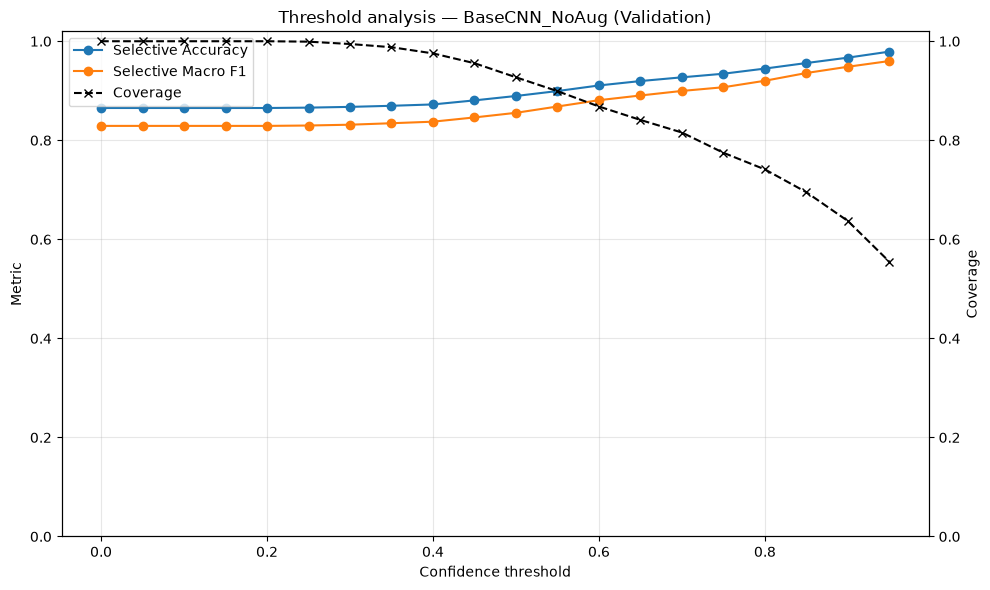

In [29]:
winner = aug_result if aug_result['val']['macro_f1'] > no_aug_result['val']['macro_f1'] else no_aug_result
print('Validation Macro F1 기준 선택 모델:', winner['name'])

def threshold_table(result, thresholds=np.arange(0.0, 0.96, 0.05)):
    y = result['targets']
    pred = result['preds']
    confidence = result['probs'].max(axis=1)
    rows = []
    for threshold in thresholds:
        accepted = confidence >= threshold
        row = {'threshold': round(float(threshold), 2), 'coverage': accepted.mean(),
               'accepted_count': int(accepted.sum())}
        if accepted.any():
            row['selective_accuracy'] = accuracy_score(y[accepted], pred[accepted])
            row['selective_macro_f1'] = f1_score(
                y[accepted], pred[accepted], labels=range(NUM_CLASSES),
                average='macro', zero_division=0)
        else:
            row['selective_accuracy'] = np.nan
            row['selective_macro_f1'] = np.nan
        rows.append(row)
    return pd.DataFrame(rows)

threshold_df = threshold_table(winner['val'])
threshold_df.to_csv(RESULT_DIR / 'BaseCNN_validation_threshold_metrics.csv', index=False)
display(threshold_df)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(threshold_df.threshold, threshold_df.selective_accuracy, marker='o', label='Selective Accuracy')
ax1.plot(threshold_df.threshold, threshold_df.selective_macro_f1, marker='o', label='Selective Macro F1')
ax1.set_xlabel('Confidence threshold'); ax1.set_ylabel('Metric'); ax1.set_ylim(0, 1.02)
ax2 = ax1.twinx()
ax2.plot(threshold_df.threshold, threshold_df.coverage, color='black', linestyle='--', marker='x', label='Coverage')
ax2.set_ylabel('Coverage'); ax2.set_ylim(0, 1.02)
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [line.get_label() for line in lines], loc='best')
ax1.grid(alpha=.3); plt.title(f"Threshold analysis — {winner['name']} (Validation)")
plt.tight_layout(); plt.savefig(RESULT_DIR / 'BaseCNN_threshold_analysis.png', dpi=150, bbox_inches='tight'); plt.show()


In [30]:
# 운영 예시: Coverage가 80% 이상인 후보 중 Selective Macro F1이 가장 높은 임계값
eligible = threshold_df[threshold_df['coverage'] >= 0.80]
selected_threshold = float(eligible.loc[eligible['selective_macro_f1'].idxmax(), 'threshold'])
print(f'Validation에서 선택한 신뢰도 임계값: {selected_threshold:.2f}')
print('이 임계값은 분류 자체를 바꾸는 값이 아니라, 자동 분류/보류를 나누는 운영 기준입니다.')


Validation에서 선택한 신뢰도 임계값: 0.70
이 임계값은 분류 자체를 바꾸는 값이 아니라, 자동 분류/보류를 나누는 운영 기준입니다.


## 12. 선택된 모델의 Test 최종 평가

Validation에서 모델과 임계값을 확정한 뒤 아래 셀을 한 번 실행합니다. 기본 전체 Test 성능과 선택된 임계값에서의 Coverage/선택적 성능을 함께 기록합니다.


In [31]:
test_result = collect_predictions(winner['model'], winner['test_loader'], nn.CrossEntropyLoss())
print(f"Final model       : {winner['name']}")
print(f"Test Accuracy      : {test_result['accuracy']:.4f}")
print(f"Test Balanced Acc. : {test_result['balanced_accuracy']:.4f}")
print(f"Test Macro F1      : {test_result['macro_f1']:.4f}")

report = classification_report(
    test_result['targets'], test_result['preds'], labels=range(NUM_CLASSES),
    target_names=class_names, output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report).T
report_df.to_csv(RESULT_DIR / 'BaseCNN_final_classification_report.csv')
display(report_df)

test_threshold_df = threshold_table(test_result, [selected_threshold])
test_threshold_df.insert(0, 'model', winner['name'])
test_threshold_df.to_csv(RESULT_DIR / 'BaseCNN_final_selected_threshold_test.csv', index=False)
display(test_threshold_df)


  0%|          | 0/73 [00:00<?, ?it/s]

Final model       : BaseCNN_NoAug
Test Accuracy      : 0.8618
Test Balanced Acc. : 0.8222
Test Macro F1      : 0.8257


,precision,recall,f1-score,support
battery,0.850340,0.880282,0.865052,142.000000
biological,0.888112,0.858108,0.872852,148.000000
brown-glass,0.857143,0.847826,0.852459,92.000000
cardboard,0.872180,0.878788,0.875472,132.000000
clothes,0.937423,0.964646,0.950840,792.000000
green-glass,0.873684,0.902174,0.887701,92.000000
metal,0.734513,0.728070,0.731278,114.000000
paper,0.879195,0.834395,0.856209,157.000000
plastic,0.714286,0.697674,0.705882,129.000000
shoes,0.806020,0.795380,0.800664,303.000000


,model,threshold,coverage,accepted_count,selective_accuracy,selective_macro_f1
0,BaseCNN_NoAug,0.7,0.812661,1887,0.939587,0.919987


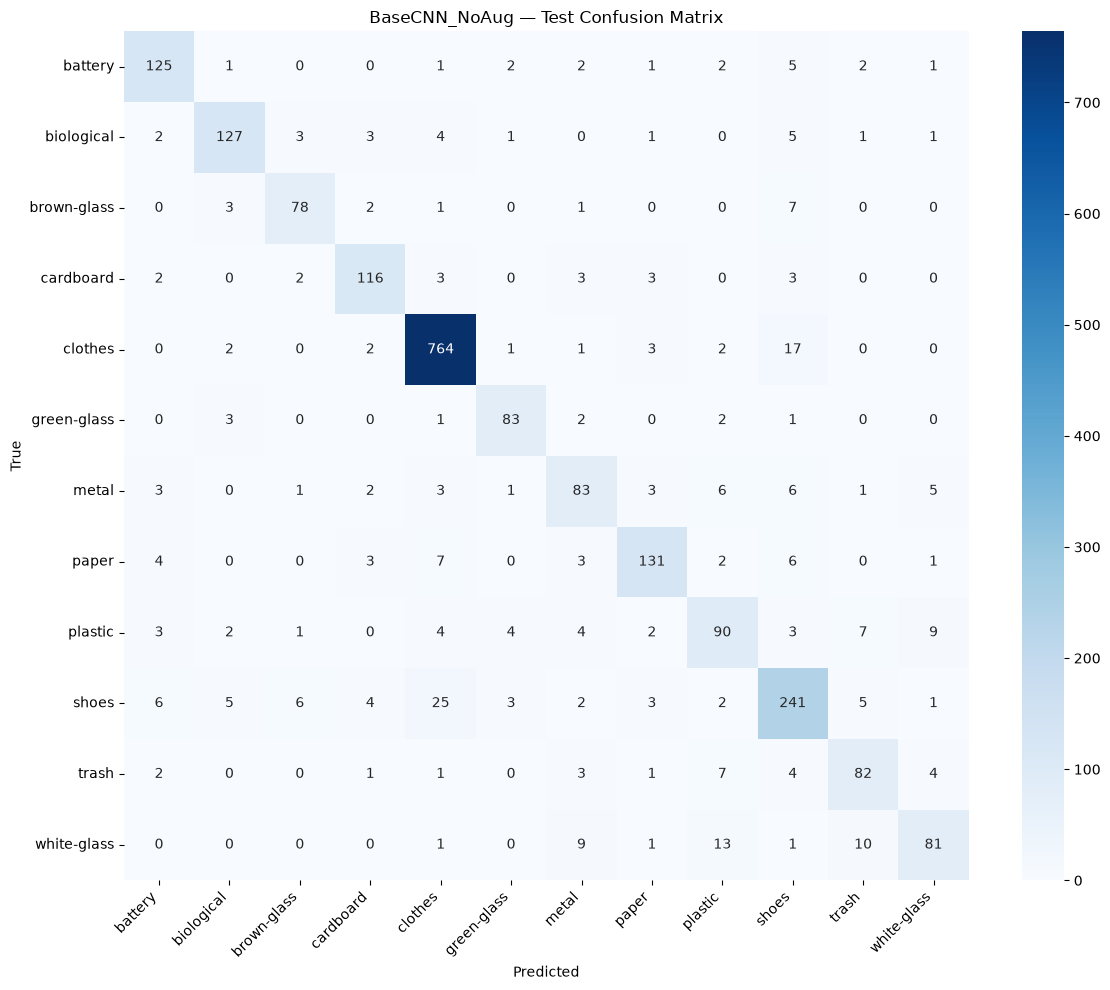

In [32]:
cm = confusion_matrix(test_result['targets'], test_result['preds'], labels=range(NUM_CLASSES))
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title(f"{winner['name']} — Test Confusion Matrix")
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0); plt.tight_layout()
plt.savefig(RESULT_DIR / 'BaseCNN_final_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [33]:
predictions_df = pd.DataFrame({
    'path': test_result['paths'],
    'true_class': [idx_to_class[i] for i in test_result['targets']],
    'pred_class': [idx_to_class[i] for i in test_result['preds']],
    'confidence': test_result['probs'].max(axis=1),
})
predictions_df['correct'] = predictions_df['true_class'].eq(predictions_df['pred_class'])
predictions_df.to_csv(RESULT_DIR / 'BaseCNN_final_test_predictions.csv', index=False)

summary = {
    'selected_model': winner['name'],
    'selection_metric': 'Validation Macro F1',
    'validation_macro_f1': float(winner['val']['macro_f1']),
    'augmentation_test_p_value': float(p_value),
    'augmentation_test_decision': decision,
    'selected_confidence_threshold': selected_threshold,
    'test_accuracy': float(test_result['accuracy']),
    'test_balanced_accuracy': float(test_result['balanced_accuracy']),
    'test_macro_f1': float(test_result['macro_f1']),
}
with open(RESULT_DIR / 'BaseCNN_assignment_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
display(pd.DataFrame([summary]))


,selected_model,selection_metric,validation_macro_f1,augmentation_test_p_value,augmentation_test_decision,selected_confidence_threshold,test_accuracy,test_balanced_accuracy,test_macro_f1
0,BaseCNN_NoAug,Validation Macro F1,0.829073,1.0,H0 기각하지 못함,0.7,0.861757,0.822214,0.825674


## 결과 해석 시 기록할 내용

1. 클래스 불균형 때문에 Macro F1을 주 지표로 선정한 이유
2. 다수 클래스 기준선보다 BaseCNN이 얼마나 개선되었는지
3. 증강 미적용/적용 조건의 Validation 지표 차이
4. 가설검정의 p-value와 `H0 기각` 또는 `H0 기각하지 못함` 결론
5. 증강을 선택하거나 제외한 이유
6. 신뢰도 임계값 증가에 따른 Coverage와 성능의 trade-off
7. 최종 Test Macro F1과 Confusion Matrix에서 자주 혼동한 클래스
